In [1]:
import sys, os, random, shutil
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.ndimage import label, find_objects
from skimage import measure
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import segmentation_models_pytorch as smp
from tqdm import tqdm
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from torch.utils.data import DataLoader, TensorDataset
%matplotlib inline

sys.path.insert(0, os.path.abspath(".."))
from wood_utils import *

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

CACHE_DIR = "./eval_cache"
OUT_DIR   = "./outputs/evaluation_3d"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUT_DIR,   exist_ok=True)


Device: cuda


In [2]:
# MODELS imported from wood_utils.config - single source of truth
# EVAL_CONDITIONS controls 2D-only vs 2D+3D-MRF comparison
EVAL_CONDITIONS = {
    "2D only":     False,
    "2D + 3D MRF": True,
}
MAX_BOUNDARY_VOXELS = 50_000
print("Models:", list(MODELS.keys()))
print("Conditions:", list(EVAL_CONDITIONS.keys()))
print("Common test logs:", COMMON_TEST_LOGS)


Models: ['DilatedCNN+MRF log-split', 'DilatedCNN+MRF random-split', 'UNet++ log-split', 'UNet++ random-split']
Conditions: ['2D only', '2D + 3D MRF']
Common test logs: ['Dub 9', 'kmen9']


In [3]:
# build_pairs already sorts by numeric page index - the slice-sort bug is fixed
all_pairs  = build_pairs(IMAGES_ROOT, GT_ROOT)
log_pairs  = group_by_log(all_pairs, IMAGES_ROOT)
all_logs   = sorted(log_pairs.keys())
test_pairs = [p for lg in COMMON_TEST_LOGS for p in log_pairs[lg]]
print(f"Total pairs: {len(all_pairs)} | Test pairs: {len(test_pairs)}")
print("First 3 test pairs:")
for p in test_pairs[:3]:
    print(" ", os.path.basename(p[0]))


Total pairs: 1347 | Test pairs: 128
First 3 test pairs:
  W1213_1_out_page_0068.tif
  W1213_1_out_page_0069.tif
  W1213_1_out_page_0070.tif


In [4]:
# build_cache_global applies one bounding box per log across all its slices.
# This fixes the lateral misalignment that per-slice crop_to_foreground caused
# when the log bends - required for correct 3D MRF, connectivity metrics, and viz.
CACHE_DIR_GLOBAL   = os.path.join(CACHE_DIR, "test_global_bbox")
cached_test_global = build_cache_global(
    test_pairs, CACHE_DIR_GLOBAL, IMAGES_ROOT, force=True
)


  Dub 9: global bbox  y:[0,778]  x:[0,778]
  kmen9: global bbox  y:[0,778]  x:[0,778]


Caching (global bbox): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 122.49it/s]

  Cache ready: 128 pairs (global bbox)


In [5]:
# DilatedSegCNN, build_unetpp, load_checkpoint - from wood_utils.models
print("Architectures available: DilatedSegCNN, build_unetpp, load_checkpoint")


Architectures available: DilatedSegCNN, build_unetpp, load_checkpoint


In [6]:
# 2D and 3D MRF - from wood_utils.mrf
# mrf_gibbs_sampling_2d : per-slice refinement
# mrf_gibbs_sampling_3d : vectorized grouped conv3d, beta=0.3, skip_classes=[4]
mrf_gibbs_sampling = mrf_gibbs_sampling_2d   # alias for cells below
print("MRF functions imported from wood_utils.mrf")


MRF functions imported from wood_utils.mrf


In [7]:
# compute_volume_metrics_3d, safe_compactness - from wood_utils.metrics
compute_3d_boundary_metrics = compute_boundary_metrics_3d
OVERLAP_METRICS = ["iou", "dice", "recall", "precision", "vs", "hd_3d", "assd_3d"]
VOLUME_METRICS  = ["volume_vox", "components", "continuity", "compactness"]
DISPLAY_CLASSES = CLASS_NAMES[1:]


In [8]:
def build_log_volumes(model_cfg, apply_3d_mrf=False):
    """
    Returns:
      gt_vols:   {log_id: (D,H,W) int64}   ground truth
      pred_vols: {log_id: (D,H,W) int64}   predictions
      prob_vols: {log_id: (C,D,H,W) float} softmax probabilities

    Uses cached_test_global: every slice is cropped with a per-log global
    bounding box, so all slices of a log share the same spatial reference
    frame.  This is required for correct 3D connectivity metrics, 3D MRF
    smoothing, and visualisation (old per-slice crop shifted the window as
    the log bends, causing cracks to jump laterally across slice boundaries).
    """
    model   = load_checkpoint(model_cfg)
    use_mrf = model_cfg["mrf"]
    beta    = model_cfg.get("mrf_beta", 0.8)

    log_to_indices = defaultdict(list)
    for i, pair in enumerate(test_pairs):
        log_to_indices[get_log_id(pair[0])].append(i)

    gt_vols = {}; pred_vols = {}; prob_vols = {}

    for log_id, indices in log_to_indices.items():
        # globally-aligned cache (replaces old cached_test)
        imgs  = np.stack([np.load(cached_test_global[i][0]) for i in indices])
        masks = np.stack([np.load(cached_test_global[i][1]) for i in indices])
        loader = DataLoader(
            TensorDataset(torch.tensor(imgs, dtype=torch.float32),
                          torch.tensor(masks, dtype=torch.long)),
            batch_size=16, shuffle=False, num_workers=0)

        slice_probs = []; slice_preds = []
        with torch.no_grad():
            for imgs_b, _ in tqdm(loader, desc=f"  {log_id}", leave=False):
                probs_b = F.softmax(model(imgs_b.to(device)), dim=1)
                if use_mrf:
                    preds_b = torch.stack([
                        mrf_gibbs_sampling_2d(probs_b[b], beta=beta)
                        for b in range(len(probs_b))]).cpu()
                else:
                    preds_b = torch.argmax(probs_b, dim=1).cpu()
                slice_probs.append(probs_b.cpu())
                slice_preds.append(preds_b)

        pred_vol = torch.cat(slice_preds, dim=0).numpy()          # (D,H,W)
        prob_vol = torch.cat(slice_probs, dim=0).numpy()           # (D,C,H,W)
        prob_vol = prob_vol.transpose(1, 0, 2, 3)                  # (C,D,H,W)

        if apply_3d_mrf:
            print(f"    Applying 3D MRF on {log_id} "
                  f"(volume shape: {prob_vol.shape})...")
            prob_tensor = torch.tensor(prob_vol, dtype=torch.float32, device=device)
            pred_vol    = mrf_gibbs_sampling_3d(
                prob_tensor,
                iterations   = model_cfg.get("mrf3d_iterations", 3),
                beta         = model_cfg.get("mrf3d_beta", 0.3),
                skip_classes = model_cfg.get("skip_classes", None),
            ).cpu().numpy()

        gt_vols[log_id]   = masks
        pred_vols[log_id] = pred_vol
        prob_vols[log_id] = prob_vol

    del model; torch.cuda.empty_cache()
    return gt_vols, pred_vols, prob_vols


In [9]:
all_conditions = {}

for model_name, model_cfg in MODELS.items():
    if not os.path.exists(model_cfg["path"]):
        print(f"Skipping '{model_name}' - not found: {model_cfg['path']}")
        continue
    all_conditions[model_name] = {}
 
    for condition_name, apply_mrf in EVAL_CONDITIONS.items():
        print(f"\n{'-'*60}")
        print(f" {model_name} - {condition_name}")
        print(f"{'-'*60}")
 
        gt_vols, pred_vols, prob_vols = build_log_volumes(
            model_cfg, apply_3d_mrf=apply_mrf)
 
        log_metrics = {}
        for log_id in gt_vols:
            log_metrics[log_id] = {}
            for c, cls_name in enumerate(CLASS_NAMES):
                m = compute_volume_metrics_3d(pred_vols[log_id], gt_vols[log_id], c)
                log_metrics[log_id][cls_name] = m
 
        all_conditions[model_name][condition_name] = {
            "metrics":   log_metrics,
            "pred_vols": pred_vols,
            "gt_vols":   gt_vols,
        }
 
print("\nAll 3D evaluations complete.")


------------------------------------------------------------
 DilatedCNN+MRF log-split - 2D only
------------------------------------------------------------



------------------------------------------------------------
 DilatedCNN+MRF log-split - 2D + 3D MRF
------------------------------------------------------------


    Applying 3D MRF on Dub 9 (volume shape: (5, 64, 256, 256))...


    Applying 3D MRF on kmen9 (volume shape: (5, 64, 256, 256))...

------------------------------------------------------------
 DilatedCNN+MRF random-split - 2D only
------------------------------------------------------------



------------------------------------------------------------
 DilatedCNN+MRF random-split - 2D + 3D MRF
------------------------------------------------------------


...

    Applying 3D MRF on Dub 9 (volume shape: (5, 64, 256, 256))...


    Applying 3D MRF on kmen9 (volume shape: (5, 64, 256, 256))...

------------------------------------------------------------
 UNet++ random-split - 2D only
------------------------------------------------------------
  UNet++ encoder: 216/216 ImageNet weights loaded



------------------------------------------------------------
 UNet++ random-split - 2D + 3D MRF
------------------------------------------------------------
  UNet++ encoder: 216/216 ImageNet weights loaded


    Applying 3D MRF on Dub 9 (volume shape: (5, 64, 256, 256))...


    Applying 3D MRF on kmen9 (volume shape: (5, 64, 256, 256))...

All 3D evaluations complete.


In [10]:
OVERLAP_METRICS = ["iou", "dice", "recall", "precision", "vs", "hd_3d", "assd_3d"]
VOLUME_METRICS  = ["volume_vox", "components", "continuity", "compactness"]
DISPLAY_CLASSES = CLASS_NAMES[1:]   # skip Background in tables - not informative
# Background is still rendered in the Plotly 3D mesh (as outer hull via Bark trace)
 
def build_results_df(metric_keys, include_gt=False):
    """
    Build a tidy DataFrame from all_conditions for given metrics.
    If include_gt=True, prepends a Ground Truth row computed as
    self-comparison (gt vs gt) for volume metric reference.
    """
    rows = []
 
    # Ground Truth rows (top of each group)
    if include_gt:
        first_res = list(list(all_conditions.values())[0].values())[0]
        for log_id, gt_vol in first_res["gt_vols"].items():
            for c, cls_name in enumerate(CLASS_NAMES):
                m = compute_volume_metrics_3d(gt_vol, gt_vol, c)
                row = {"Model": "Ground Truth", "Condition": "-",
                       "Log": log_id, "Class": cls_name}
                for metric in metric_keys:
                    v = m[metric]
                    row[metric] = round(v, 4) if not np.isnan(v) else float("nan")
                rows.append(row)
 
    # Model rows
    for model_name, conditions in all_conditions.items():
        for condition_name, res in conditions.items():
            for log_id, log_data in res["metrics"].items():
                for cls_name, m in log_data.items():
                    row = {"Model": model_name, "Condition": condition_name,
                           "Log": log_id, "Class": cls_name}
                    for metric in metric_keys:
                        v = m[metric]
                        row[metric] = round(v, 4) if not np.isnan(v) else float("nan")
                    rows.append(row)
    return pd.DataFrame(rows)
 
 
def show_table(df, title, note=""):
    """
    Display results as pandas styled tables.
    - One table per class per log
    - Ground Truth row always at top, no highlighting applied to it
    - Highlighting among model rows only, per log group
    - components highlighted as lower=better
    - All numeric values formatted to 4 decimal places
    """
    from IPython.display import display as ipy_display
    print(f"\n{'='*80}")
    print(f"  {title}")
    if note:
        print(f"  {note}")
    print(f"{'='*80}")
 
    metric_cols   = [c for c in df.columns if c not in ["Model","Condition","Log","Class"]]
    # lower is better: boundary distances, compactness, components
    lower_better  = [m for m in metric_cols
                 if m in ["hd_3d", "assd_3d", "compactness", "components"]]
    higher_better = [m for m in metric_cols
                 if m in ["iou", "dice", "recall", "precision", "vs", "continuity"]]
 
    fmt_dict = {m: "{:.3f}" for m in metric_cols}
    fmt_dict.update({"volume_vox": "{:.0f}", "components": "{:.0f}"})
 
    for cls_name in DISPLAY_CLASSES:
        sub = df[df["Class"] == cls_name].drop(columns="Class")
        if sub.empty:
            continue
        print(f"\n  -- {cls_name}")
 
        for log_id in sorted(sub["Log"].unique()):
            log_sub = sub[sub["Log"] == log_id].drop(columns="Log")
 
            # split GT from models - GT always first, no sorting needed
            gt_rows    = log_sub[log_sub["Model"] == "Ground Truth"]
            model_rows = (log_sub[log_sub["Model"] != "Ground Truth"]
                          .sort_values(["Model","Condition"])
                          .reset_index(drop=True))
 
            # recombine: GT on top, models below
            combined = pd.concat([gt_rows, model_rows]).reset_index(drop=True)
            gt_idx   = combined[combined["Model"] == "Ground Truth"].index.tolist()
            print(f"    {log_id}")
 
            def highlight_best(df_s, hb=higher_better, lb=lower_better,
                                skip=gt_idx):
                styles = pd.DataFrame("", index=df_s.index, columns=df_s.columns)
                # only highlight model rows (skip GT rows)
                model_idx = [i for i in df_s.index if i not in skip]
                if not model_idx:
                    return styles
                for col in hb:
                    if col not in df_s.columns: continue
                    vals = pd.to_numeric(df_s.loc[model_idx, col], errors="coerce")
                    if vals.notna().any():
                        styles.loc[vals.idxmax(), col] =                             "background-color: #d4edda; font-weight: bold"
                for col in lb:
                    if col not in df_s.columns: continue
                    vals = pd.to_numeric(df_s.loc[model_idx, col], errors="coerce")
                    if vals.notna().any():
                        styles.loc[vals.idxmin(), col] =                             "background-color: #d4edda; font-weight: bold"
                return styles
 
            def style_gt_row(df_s, skip=gt_idx):
                """Light grey background for GT row."""
                styles = pd.DataFrame("", index=df_s.index, columns=df_s.columns)
                for i in skip:
                    styles.loc[i, :] = "background-color: #f0f0f0; font-style: italic"
                return styles
 
            styled = (combined.style
                      .apply(highlight_best, axis=None)
                      .apply(style_gt_row,   axis=None)
                      .format(fmt_dict, na_rep="n/a")
                      .set_properties(**{"text-align": "center"})
                      .set_table_styles([
                          {"selector": "th",
                           "props": [("text-align","center"),("font-weight","bold"),
                                     ("background-color","#e8e8e8")]},
                          {"selector": "tr:hover",
                           "props": [("background-color","#fafafa")]},
                      ]))
            ipy_display(styled)
 
# build dataframes
df_overlap = build_results_df(OVERLAP_METRICS, include_gt=False)
df_volume  = build_results_df(VOLUME_METRICS,  include_gt=True)
 
show_table(
    df_overlap,
    "A) Overlap Metrics - agreement with 2D GT annotations",
    note="Note: 3D MRF may reduce overlap metrics because GT was annotated "
         "slice-by-slice without enforcing 3D consistency."
)
 
show_table(
    df_volume,
    "B) Volume Metrics - anatomical plausibility of 3D structure",
    note="3D MRF expected to improve these (fewer fragments, higher continuity)."
)
 
# save both to csv
df_overlap.to_csv(os.path.join(OUT_DIR, "3d_overlap_metrics.csv"), index=False)
df_volume.to_csv(os.path.join(OUT_DIR, "3d_volume_metrics.csv"),  index=False)
print(f"\nSaved -> {OUT_DIR}/3d_overlap_metrics.csv")
print(f"Saved -> {OUT_DIR}/3d_volume_metrics.csv")


  A) Overlap Metrics - agreement with 2D GT annotations
  Note: 3D MRF may reduce overlap metrics because GT was annotated slice-by-slice without enforcing 3D consistency.

  -- Bark
    Dub 9


,Model,Condition,iou,dice,recall,precision,vs,hd_3d,assd_3d
0,DilatedCNN+MRF log-split,2D + 3D MRF,0.709,0.830,0.930,0.749,0.892,n/a,n/a
1,DilatedCNN+MRF log-split,2D only,0.711,0.831,0.931,0.750,0.892,n/a,n/a
2,DilatedCNN+MRF random-split,2D + 3D MRF,0.671,0.803,0.959,0.692,0.838,n/a,n/a
3,DilatedCNN+MRF random-split,2D only,0.671,0.803,0.958,0.692,0.839,n/a,n/a
4,UNet++ log-split,2D + 3D MRF,0.636,0.778,0.968,0.650,0.803,n/a,n/a
5,UNet++ log-split,2D only,0.639,0.779,0.969,0.652,0.804,n/a,n/a
6,UNet++ random-split,2D + 3D MRF,0.649,0.787,0.974,0.661,0.808,n/a,n/a
7,UNet++ random-split,2D only,0.653,0.790,0.976,0.664,0.809,n/a,n/a


    kmen9


,Model,Condition,iou,dice,recall,precision,vs,hd_3d,assd_3d
0,DilatedCNN+MRF log-split,2D + 3D MRF,0.490,0.658,0.894,0.520,0.736,n/a,n/a
1,DilatedCNN+MRF log-split,2D only,0.475,0.644,0.896,0.503,0.719,n/a,n/a
2,DilatedCNN+MRF random-split,2D + 3D MRF,0.614,0.761,0.885,0.668,0.860,n/a,n/a
3,DilatedCNN+MRF random-split,2D only,0.601,0.751,0.886,0.652,0.848,n/a,n/a
4,UNet++ log-split,2D + 3D MRF,0.761,0.865,0.867,0.862,0.997,n/a,n/a
5,UNet++ log-split,2D only,0.769,0.869,0.882,0.857,0.986,n/a,n/a
6,UNet++ random-split,2D + 3D MRF,0.714,0.833,0.917,0.763,0.909,n/a,n/a
7,UNet++ random-split,2D only,0.684,0.813,0.933,0.720,0.871,n/a,n/a



  -- Wood
    Dub 9


...


  -- Crack
    Dub 9


,Model,Condition,volume_vox,components,continuity,compactness
0,Ground Truth,-,106,30,0.179,n/a
1,DilatedCNN+MRF log-split,2D + 3D MRF,1105,231,0.298,17.680
2,DilatedCNN+MRF log-split,2D only,316,48,0.576,17.510
3,DilatedCNN+MRF random-split,2D + 3D MRF,593,172,0.336,16.121
4,DilatedCNN+MRF random-split,2D only,200,43,0.415,14.703
5,UNet++ log-split,2D + 3D MRF,566,61,0.367,27.004
6,UNet++ log-split,2D only,566,61,0.367,27.004
7,UNet++ random-split,2D + 3D MRF,318,66,0.390,34.779
8,UNet++ random-split,2D only,318,66,0.390,34.779


    kmen9


,Model,Condition,volume_vox,components,continuity,compactness
0,Ground Truth,-,4062,182,0.801,44.164
1,DilatedCNN+MRF log-split,2D + 3D MRF,2728,132,0.411,40.373
2,DilatedCNN+MRF log-split,2D only,2151,111,0.492,35.732
3,DilatedCNN+MRF random-split,2D + 3D MRF,2005,247,0.214,39.276
4,DilatedCNN+MRF random-split,2D only,1451,210,0.151,35.325
5,UNet++ log-split,2D + 3D MRF,2968,49,0.641,44.171
6,UNet++ log-split,2D only,2968,49,0.641,44.171
7,UNet++ random-split,2D + 3D MRF,2378,177,0.157,33.921
8,UNet++ random-split,2D only,2378,177,0.157,33.921



Saved -> ./outputs/evaluation_3d/3d_overlap_metrics.csv
Saved -> ./outputs/evaluation_3d/3d_volume_metrics.csv


In [11]:
# -----------------------------------------------------------------------------
# Z-AXIS MORPHOLOGICAL CLOSING - crack continuity experiment
#
# Applies binary_closing along the depth (z) axis only, using a
# (z_extent, 1, 1) structuring element.  This bridges isolated crack
# fragments across consecutive slices WITHOUT expanding crack width laterally.
#
# Applied to PREDICTIONS only - GT is left unchanged.
# Reason: closing the GT would invent annotations and corrupt the reference.
# The meaningful signal is in the volume proxy metrics (components, continuity),
# not in IoU (which stays flat or drops slightly because the fragmented GT
# cannot "reward" a now-continuous prediction).
#
# Three z_extent values are tested:  3, 5, 7
#   z_extent=3  bridges up to 2 missing slices
#   z_extent=5  bridges up to 4 missing slices
#   z_extent=7  bridges up to 6 missing slices
# -----------------------------------------------------------------------------

import numpy as np
from scipy.ndimage import binary_closing

CRACK_CLASS = 4   # index in CLASS_NAMES

def apply_z_closing(pred_vol, class_idx=CRACK_CLASS, z_extent=3):
    """
    Close gaps in class_idx along the depth axis only.

    pred_vol  : (D, H, W) int64 label volume
    class_idx : class to close (default: Crack)
    z_extent  : length of the 1-D structuring element along z
                (must be odd; bridges up to z_extent-1 missing slices)
    Returns a copy of pred_vol with the crack mask closed along z.
    """
    struct = np.zeros((z_extent, 1, 1), dtype=bool)
    struct[:, 0, 0] = True                    # depth-only structuring element

    crack_mask = (pred_vol == class_idx)
    closed     = binary_closing(crack_mask, structure=struct)

    out = pred_vol.copy()
    # Only fill NEW voxels - never override existing non-crack labels
    out[closed & ~crack_mask] = class_idx
    return out


Z_EXTENTS = [3, 5, 7]

# Build a new conditions dict in the same format as all_conditions
# key: "Z-close z=N (base: <condition>)" for each base condition × z_extent
z_close_conditions = {}

for base_condition in ["2D only", "2D + 3D MRF"]:
    for z in Z_EXTENTS:
        new_key = f"Z-close z={z} ({base_condition})"
        print(f"  Running {new_key} ...")

        log_metrics_zc = {}
        pred_vols_zc   = {}

        base = all_conditions          # already computed above
        # iterate over models that were successfully evaluated
        for model_name in base:
            if base_condition not in base[model_name]:
                continue

            res      = base[model_name][base_condition]
            gt_vols  = res["gt_vols"]
            pred_vols_orig = res["pred_vols"]

            if model_name not in log_metrics_zc:
                log_metrics_zc[model_name] = {}
                pred_vols_zc[model_name]   = {}

            for log_id in gt_vols:
                closed_vol = apply_z_closing(pred_vols_orig[log_id],
                                             class_idx=CRACK_CLASS,
                                             z_extent=z)
                pred_vols_zc[model_name][log_id] = closed_vol

                log_metrics_zc[model_name][log_id] = {}
                for c, cls_name in enumerate(CLASS_NAMES):
                    m = compute_volume_metrics_3d(
                            closed_vol, gt_vols[log_id], c)
                    log_metrics_zc[model_name][log_id][cls_name] = m

        z_close_conditions[new_key] = {
            "base_condition": base_condition,
            "z_extent":       z,
            "metrics":        log_metrics_zc,
            "pred_vols":      pred_vols_zc,
        }

print("\nZ-axis closing complete.")

  Running Z-close z=3 (2D only) ...
  Running Z-close z=5 (2D only) ...
  Running Z-close z=7 (2D only) ...
  Running Z-close z=3 (2D + 3D MRF) ...
  Running Z-close z=5 (2D + 3D MRF) ...
  Running Z-close z=7 (2D + 3D MRF) ...

Z-axis closing complete.


In [12]:
# -----------------------------------------------------------------------------
# COMPARISON TABLE  -  Crack / kmen9  :  original vs. z-closed
# Focus on volume proxy metrics (components, continuity) because:
#   - IoU is bounded by GT fragmentation (264 GT components)
#   - Component count and continuity measure anatomical plausibility
# -----------------------------------------------------------------------------

import pandas as pd

TARGET_LOG   = "kmen9"
TARGET_CLASS = "Crack"

rows = []

# 1. Ground truth reference
gt_vol = list(list(all_conditions.values())[0]["2D only"]["gt_vols"].values())
# find the kmen9 gt
gt_vol_km = all_conditions[list(all_conditions.keys())[0]]["2D only"]["gt_vols"][TARGET_LOG]
m_gt = compute_volume_metrics_3d(gt_vol_km, gt_vol_km, CRACK_CLASS)
rows.append({
    "Model": "Ground Truth", "Condition": "-", "z_extent": "-",
    "IoU": "-",
    "Recall": "-",
    "VS": "-",
    "Components": m_gt["components"],
    "Continuity": round(m_gt["continuity"], 3),
    "Compactness": round(m_gt["compactness"], 2) if m_gt["compactness"] else "n/a",
})

# 2. Baseline (no closing)
for model_name in all_conditions:
    for cond in ["2D only", "2D + 3D MRF"]:
        if cond not in all_conditions[model_name]:
            continue
        m = all_conditions[model_name][cond]["metrics"][TARGET_LOG][TARGET_CLASS]
        rows.append({
            "Model": model_name, "Condition": cond, "z_extent": "none",
            "IoU":        round(m["iou"],        3),
            "Recall":     round(m["recall"],     3),
            "VS":         round(m["vs"],         3),
            "Components": m["components"],
            "Continuity": round(m["continuity"], 3),
            "Compactness":round(m["compactness"],2) if m["compactness"] else "n/a",
        })

# 3. Z-closed variants
for new_key, zcdata in z_close_conditions.items():
    for model_name in zcdata["metrics"]:
        m = zcdata["metrics"][model_name][TARGET_LOG][TARGET_CLASS]
        rows.append({
            "Model": model_name,
            "Condition": zcdata["base_condition"],
            "z_extent": zcdata["z_extent"],
            "IoU":        round(m["iou"],        3),
            "Recall":     round(m["recall"],     3),
            "VS":         round(m["vs"],         3),
            "Components": m["components"],
            "Continuity": round(m["continuity"], 3),
            "Compactness":round(m["compactness"],2) if m["compactness"] else "n/a",
        })

df = pd.DataFrame(rows)

# Style: highlight Components and Continuity as the meaningful columns
styled = (df.style
    .set_caption(f"Z-axis closing effect - Crack class, {TARGET_LOG}  "
                 f"(GT has {int(df.loc[0,'Components'])} components as reference)")
    .background_gradient(subset=["Components"], cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["Continuity"], cmap="RdYlGn",   axis=0)
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "13px"),
                                  ("font-weight", "bold"),
                                  ("text-align", "left")]}])
)
display(styled)

,Model,Condition,z_extent,IoU,Recall,VS,Components,Continuity,Compactness
0,Ground Truth,-,-,-,-,-,182,0.801000,44.160000
1,DilatedCNN+MRF log-split,2D only,none,0.440000,0.468000,0.692000,111,0.492000,35.730000
2,DilatedCNN+MRF log-split,2D + 3D MRF,none,0.518000,0.570000,0.804000,132,0.411000,40.370000
3,DilatedCNN+MRF random-split,2D only,none,0.322000,0.331000,0.526000,210,0.151000,35.320000
4,DilatedCNN+MRF random-split,2D + 3D MRF,none,0.410000,0.435000,0.661000,247,0.214000,39.280000
5,UNet++ log-split,2D only,none,0.496000,0.574000,0.844000,49,0.641000,44.170000
6,UNet++ log-split,2D + 3D MRF,none,0.496000,0.574000,0.844000,49,0.641000,44.170000
7,UNet++ random-split,2D only,none,0.448000,0.491000,0.739000,177,0.157000,33.920000
8,UNet++ random-split,2D + 3D MRF,none,0.448000,0.491000,0.739000,177,0.157000,33.920000
9,DilatedCNN+MRF log-split,2D only,3,0.446000,0.477000,0.706000,103,0.653000,35.700000


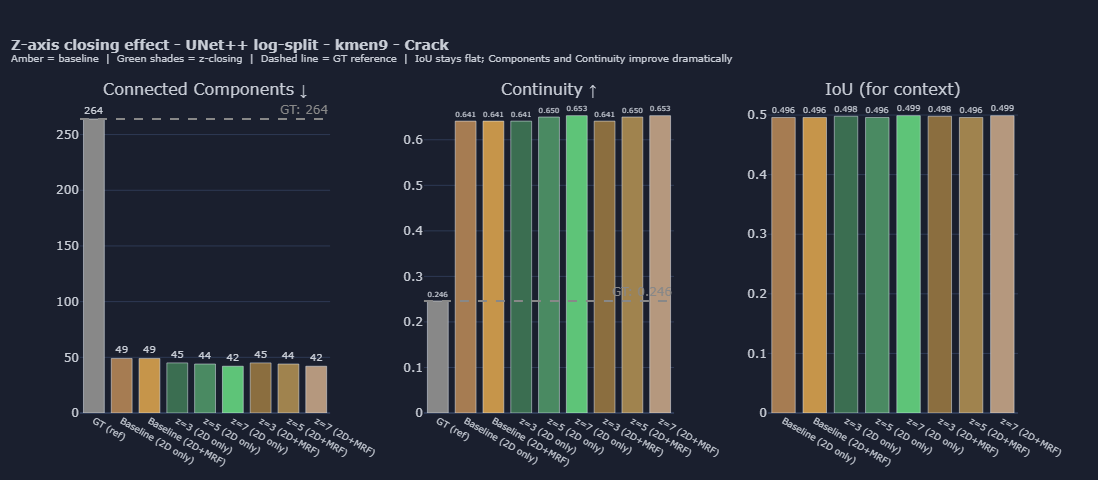

In [13]:
import plotly.graph_objects as go

TARGET_LOG   = "kmen9"
TARGET_MODEL = "UNet++ log-split"
MODEL_FILTER = TARGET_MODEL
CONDITIONS   = ["2D only", "2D + 3D MRF"]

# Extract the data points in order
x_labels = ["GT\n(ref)", "Baseline\n(2D only)", "Baseline\n(2D+MRF)",
             "z=3\n(2D only)", "z=5\n(2D only)", "z=7\n(2D only)",
             "z=3\n(2D+MRF)", "z=5\n(2D+MRF)", "z=7\n(2D+MRF)"]

# Filter df for this model
sub = df[df["Model"] == MODEL_FILTER].copy()

def get_val(cond, z, col):
    row = sub[(sub["Condition"] == cond) & (sub["z_extent"] == z)]
    if row.empty:
        return None
    v = row[col].values[0]
    return float(v) if v != "n/a" else None

components = [
    264,  # GT
    get_val("2D only",     "none", "Components"),
    get_val("2D + 3D MRF", "none", "Components"),
    get_val("2D only",     3,      "Components"),
    get_val("2D only",     5,      "Components"),
    get_val("2D only",     7,      "Components"),
    get_val("2D + 3D MRF", 3,      "Components"),
    get_val("2D + 3D MRF", 5,      "Components"),
    get_val("2D + 3D MRF", 7,      "Components"),
]

continuity = [
    0.246,  # GT
    get_val("2D only",     "none", "Continuity"),
    get_val("2D + 3D MRF", "none", "Continuity"),
    get_val("2D only",     3,      "Continuity"),
    get_val("2D only",     5,      "Continuity"),
    get_val("2D only",     7,      "Continuity"),
    get_val("2D + 3D MRF", 3,      "Continuity"),
    get_val("2D + 3D MRF", 5,      "Continuity"),
    get_val("2D + 3D MRF", 7,      "Continuity"),
]

iou_vals = [
    None,   # GT has no IoU
    get_val("2D only",     "none", "IoU"),
    get_val("2D + 3D MRF", "none", "IoU"),
    get_val("2D only",     3,      "IoU"),
    get_val("2D only",     5,      "IoU"),
    get_val("2D only",     7,      "IoU"),
    get_val("2D + 3D MRF", 3,      "IoU"),
    get_val("2D + 3D MRF", 5,      "IoU"),
    get_val("2D + 3D MRF", 7,      "IoU"),
]

BG = "rgba(26,31,46,1)"
AMBER = "#A67C52"
GREEN = "#3B6E51"
LGRN  = "#5EC478"

fig2 = make_subplots(
    rows=1, cols=3,
    subplot_titles=["Connected Components ↓", "Continuity ↑", "IoU (for context)"],
    horizontal_spacing=0.1,
)

# colour: grey for GT, amber for baselines, green shades for z-close
colors = ["#888888", AMBER, "#C6954A",
          GREEN, "#4A8A62", LGRN,
          "#8B6E3F", "#A0834E", "#B5987E"]

for i, (x, comp, cont, iou, col) in enumerate(
        zip(x_labels, components, continuity, iou_vals, colors)):

    marker_kw = dict(color=col, size=10, line=dict(color="white", width=1.5))

    if comp is not None:
        fig2.add_trace(go.Bar(x=[x], y=[comp], marker_color=col,
                              showlegend=False,
                              text=[str(int(comp))], textposition="outside",
                              textfont=dict(size=10, color="#C8CDD6")),
                       row=1, col=1)

    if cont is not None:
        fig2.add_trace(go.Bar(x=[x], y=[cont], marker_color=col,
                              showlegend=False,
                              text=[f"{cont:.3f}"], textposition="outside",
                              textfont=dict(size=10, color="#C8CDD6")),
                       row=1, col=2)

    if iou is not None:
        fig2.add_trace(go.Bar(x=[x], y=[iou], marker_color=col,
                              showlegend=False,
                              text=[f"{iou:.3f}"], textposition="outside",
                              textfont=dict(size=10, color="#C8CDD6")),
                       row=1, col=3)

# GT reference lines
fig2.add_hline(y=264,   line_dash="dash", line_color="#888888",
               annotation_text="GT: 264", row=1, col=1,
               annotation_font_color="#888888")
fig2.add_hline(y=0.246, line_dash="dash", line_color="#888888",
               annotation_text="GT: 0.246", row=1, col=2,
               annotation_font_color="#888888")

fig2.update_layout(
    title=dict(
        text=f"<b>Z-axis closing effect - {TARGET_MODEL} - {TARGET_LOG} - Crack</b>"
             "<br><sup>Amber = baseline  |  Green shades = z-closing  |  "
             "Dashed line = GT reference  |  IoU stays flat; Components and Continuity improve dramatically</sup>",
        font=dict(size=14, color="#C8CDD6"), x=0.01,
    ),
    paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(color="#C8CDD6"),
    height=480,
    margin=dict(t=100, b=60),
    bargap=0.25,
)
fig2.update_yaxes(gridcolor="#2E3A55", zerolinecolor="#2E3A55")
fig2.update_xaxes(tickfont=dict(size=9))

fig2.show()

In [14]:
model_names = list(all_conditions.keys()) 

def make_mesh_traces(volume_3d, spacing=(10,1,1), defect_only=False,
                     opacity_full=0.15, opacity_defect=0.7, show_legend=True):
    """
    Build Plotly Mesh3d traces from (D,H,W) label volume.
    Bark (c=1) rendered as outer hull of entire log - same as mesh_viewer.py.
    """
    traces = []; volume_3d = volume_3d.astype(np.uint8)
    classes = [3, 4] if defect_only else list(range(1, NUM_CLASSES))
    opacity = opacity_defect if defect_only else opacity_full
 
    for c in classes:
        cls_name = CLASS_NAMES[c]
        mask     = (volume_3d != 0) if (c == 1 and not defect_only) else (volume_3d == c)
        if np.count_nonzero(mask) == 0:
            continue
        try:
            verts, faces, _, _ = measure.marching_cubes(
                mask.astype(np.float32), level=0.5, spacing=spacing)
            traces.append(go.Mesh3d(
                x=verts[:,0], y=verts[:,1], z=verts[:,2],
                i=faces[:,0], j=faces[:,1], k=faces[:,2],
                color=CLASS_COLORS_PLOTLY[c], opacity=opacity,
                name=cls_name, flatshading=True,
                lighting=dict(ambient=0.5, diffuse=0.5),
                legendgroup=f"class_{c}", showlegend=show_legend,
            ))
        except Exception as e:
            print(f"  Skipping {cls_name}: {e}")
    return traces
 
def visualise_3d_comparison(log_id, gt_vol, pred_vols_dict,
                             spacing=(10,1,1), defect_only=False):
    """
    Side-by-side Plotly 3D: GT | model1 | model2 | ...
    One subplot per column. Interactive - click legend to toggle classes.
    """
    col_titles = ["Ground Truth"] + list(pred_vols_dict.keys())
    n_cols     = len(col_titles)
    fig = make_subplots(
        rows=1, cols=n_cols,
        specs=[[{"type":"mesh3d"}]*n_cols],
        subplot_titles=col_titles,
        horizontal_spacing=0.02,
    )
    scene_cfg = dict(
        aspectmode="data",
        camera=dict(eye=dict(x=-3.2, y=-4, z=0.8)),
        xaxis_title="Depth", yaxis_title="Width", zaxis_title="Height",
    )
 
    for trace in make_mesh_traces(gt_vol, spacing, defect_only):
        fig.add_trace(trace, row=1, col=1)
    for col_i, (model_name, pred_vol) in enumerate(pred_vols_dict.items(), start=2):
        for trace in make_mesh_traces(pred_vol, spacing, defect_only, show_legend=False):
            fig.add_trace(trace, row=1, col=col_i)
 
    for col_i in range(1, n_cols+1):
        fig.update_layout(**{
            ("scene" if col_i==1 else f"scene{col_i}"): scene_cfg})
 
    tag = "Defect-only" if defect_only else "Full segmentation"
    fig.update_layout(
        title=dict(text=f"3D {tag} - {log_id}", font=dict(size=15)),
        height=600, margin=dict(l=0,r=0,b=0,t=60),
        showlegend=True, legend_itemclick="toggle",
        legend_itemdoubleclick="toggleothers", uirevision="constant",
    )
    return fig
 
 
# render figures - one per log per condition
# use 2D-only predictions for the default view (more comparable to 2D eval)
# 3D MRF versions saved separately
 
for log_id in COMMON_TEST_LOGS:
    gt_vol = list(all_conditions.values())[0]["2D only"]["gt_vols"][log_id]
 
    for condition_name in EVAL_CONDITIONS:
        pred_vols_for_log = {
            model_name: all_conditions[model_name][condition_name]["pred_vols"][log_id]
            for model_name in model_names
            if condition_name in all_conditions[model_name]
            and log_id in all_conditions[model_name][condition_name]["pred_vols"]
        }
 
        cond_tag = condition_name.replace(" ","_").replace("+","")
 
        # full segmentation
        print(f"\nRendering full 3D: {log_id} - {condition_name}")
        fig = visualise_3d_comparison(log_id, gt_vol, pred_vols_for_log)
        #display(fig)
        out = os.path.join(OUT_DIR, f"3d_full_{log_id.replace(' ','_')}_{cond_tag}.html")
        fig.write_html(out); print(f"Saved -> {out}")
 
        # defect-only
        print(f"Rendering defect-only 3D: {log_id} - {condition_name}")
        fig2 = visualise_3d_comparison(log_id, gt_vol, pred_vols_for_log, defect_only=True)
        #display(fig2)
        out2 = os.path.join(OUT_DIR, f"3d_defects_{log_id.replace(' ','_')}_{cond_tag}.html")
        fig2.write_html(out2); print(f"Saved -> {out2}")


Rendering full 3D: Dub 9 - 2D only
Saved -> ./outputs/evaluation_3d\3d_full_Dub_9_2D_only.html
Rendering defect-only 3D: Dub 9 - 2D only
Saved -> ./outputs/evaluation_3d\3d_defects_Dub_9_2D_only.html

Rendering full 3D: Dub 9 - 2D + 3D MRF
Saved -> ./outputs/evaluation_3d\3d_full_Dub_9_2D__3D_MRF.html
Rendering defect-only 3D: Dub 9 - 2D + 3D MRF
Saved -> ./outputs/evaluation_3d\3d_defects_Dub_9_2D__3D_MRF.html

Rendering full 3D: kmen9 - 2D only
Saved -> ./outputs/evaluation_3d\3d_full_kmen9_2D_only.html
Rendering defect-only 3D: kmen9 - 2D only
Saved -> ./outputs/evaluation_3d\3d_defects_kmen9_2D_only.html

Rendering full 3D: kmen9 - 2D + 3D MRF
Saved -> ./outputs/evaluation_3d\3d_full_kmen9_2D__3D_MRF.html
Rendering defect-only 3D: kmen9 - 2D + 3D MRF
Saved -> ./outputs/evaluation_3d\3d_defects_kmen9_2D__3D_MRF.html


In [15]:
TARGET_LOG   = "kmen9"
TARGET_MODEL = "UNet++ log-split"

gt_vol = all_conditions[TARGET_MODEL]["2D only"]["gt_vols"][TARGET_LOG]

pred_vols_zclose = {
    "Baseline (2D only)": all_conditions[TARGET_MODEL]["2D only"]["pred_vols"][TARGET_LOG],
    "Z-close z=3":        z_close_conditions[f"Z-close z=3 (2D only)"]["pred_vols"][TARGET_MODEL][TARGET_LOG],
    "Z-close z=5":        z_close_conditions[f"Z-close z=5 (2D only)"]["pred_vols"][TARGET_MODEL][TARGET_LOG],
    "Z-close z=7":        z_close_conditions[f"Z-close z=7 (2D only)"]["pred_vols"][TARGET_MODEL][TARGET_LOG],
}

# Full segmentation view
fig_full = visualise_3d_comparison(
    f"{TARGET_LOG} - {TARGET_MODEL} - Z-axis closing effect",
    gt_vol, pred_vols_zclose,
    defect_only=False,
)
fig_full.write_html(os.path.join(OUT_DIR, f"3d_full_{TARGET_LOG}_zclose_{TARGET_MODEL.replace('++ ','pp_').replace(' ','-')}.html"))

# Defect-only view (more readable for crack comparison)
fig_def = visualise_3d_comparison(
    f"{TARGET_LOG} - {TARGET_MODEL} - Z-axis closing effect (defects only)",
    gt_vol, pred_vols_zclose,
    defect_only=True,
)
fig_def.write_html(os.path.join(OUT_DIR, f"3d_defects_{TARGET_LOG}_zclose_{TARGET_MODEL.replace('++ ','pp_').replace(' ','-')}.html"))